In [1]:
!pip install -U "pandas" "indic-nlp-library" "transformers[torch]" "datasets" "httpx==0.24.0" "accelerate>=0.26.0" "scikit-learn"
!git clone https://github.com/anoopkunchukuttan/indic_nlp_resources.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.3/75.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully 

Cloning into 'indic_nlp_resources'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 139 (delta 2), reused 2 (delta 0), pack-reused 126 (from 1)
Receiving objects: 100% (139/139), 149.77 MiB | 32.40 MiB/s, done.
Resolving deltas: 100% (53/53), done.


In [1]:
from indicnlp import common
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
import pandas as pd
from sklearn.model_selection import train_test_split
import re
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoTokenizer
from datasets import Dataset
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Set up IndicNLP
common.set_resources_path("./indic_nlp_resources")
factory = IndicNormalizerFactory()
normalizer = factory.get_normalizer("ta")

# Load and clean data (assuming your CSV is uploaded to Colab as 'Tamil-News-Headlines.csv')
df = pd.read_csv('Tamil-News-Headlines.csv', encoding='utf-8')  # Or use 'utf-8-sig' if BOM issue

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\u0B80-\u0BFF\s.,!?]', '', text)
    return normalizer.normalize(text.strip()) if text.strip() else ""

df['News'] = df['News'].apply(clean_text)
df_train = df[['News', 'Authenticity']].copy()
df_train.columns = ['text', 'label']

# Split data (80/10/10)
train_df, temp_df = train_test_split(df_train, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 4180, Val: 523, Test: 523


In [21]:
# Model ID
model_id = "google/muril-base-cased"

# Training args (same as yours, with push to hub)
training_args = TrainingArguments(
    output_dir='./results_muril',
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to=[],
    logging_strategy="epoch",
    save_total_limit=2,
    seed=42,
    fp16=True  # GPU acceleration
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    return {"accuracy": acc, "f1": f1}

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2)

# Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128  # Good for headlines
    )

# Prepare datasets
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tokenize_function, batched=True)
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True)).map(tokenize_function, batched=True)
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True)).map(tokenize_function, batched=True)

train_ds = train_ds.rename_column("label", "labels").remove_columns(["text"])
val_ds = val_ds.rename_column("label", "labels").remove_columns(["text"])
test_ds = test_ds.rename_column("label", "labels").remove_columns(["text"])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

# Train and push to hub
trainer.train()
# trainer.push_to_hub()  # Uploads the best model - REMOVED

# Evaluate on test set
test_results = trainer.evaluate(test_ds)
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f} | F1: {test_results['eval_f1']:.4f}")

# Explicitly save the best model and tokenizer locally after training
final_save_path = "./final_trained_model"
model.save_pretrained(final_save_path)
tokenizer.save_pretrained(final_save_path)
print(f"Best model and tokenizer explicitly saved to {final_save_path}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4180 [00:00<?, ? examples/s]

Map:   0%|          | 0/523 [00:00<?, ? examples/s]

Map:   0%|          | 0/523 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.388300,0.163091,0.954111,0.954717
2,0.100500,0.108008,0.975143,0.976234
3,0.034700,0.107042,0.980880,0.981550
4,0.018700,0.110930,0.982792,0.983486
5,0.008700,0.127137,0.978967,0.979742
6,0.005600,0.124699,0.980880,0.981618
7,0.005100,0.128938,0.980880,0.981752
8,0.002400,0.123614,0.980880,0.981618


Test Accuracy: 0.9790 | F1: 0.9808
Best model and tokenizer explicitly saved to ./final_trained_model


In [22]:
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1 Score: {test_results['eval_f1']:.4f}")

Test Accuracy: 0.9790
Test F1 Score: 0.9808


In [23]:
# Evaluate on training set
train_results = trainer.evaluate(train_ds)
print(f"Train Accuracy: {train_results['eval_accuracy']:.4f} | F1: {train_results['eval_f1']:.4f}")

print(f"Validation Accuracy: {test_results['eval_accuracy']:.4f} | F1: {test_results['eval_f1']:.4f}")
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f} | F1: {test_results['eval_f1']:.4f}")

Train Accuracy: 0.9986 | F1: 0.9987
Validation Accuracy: 0.9790 | F1: 0.9808
Test Accuracy: 0.9790 | F1: 0.9808


Based on the latest evaluation metrics after training with 8 epochs:

*   **Train Accuracy: 0.9986 | F1: 0.9987**
*   **Validation Accuracy: 0.9790 | F1: 0.9808**
*   **Test Accuracy: 0.9790 | F1: 0.9808**

**Analysis:**

This updated performance profile is highly positive:

1.  **No Underfitting:** The significantly improved training accuracy and F1 score (nearly 100%) demonstrate that the model has now successfully learned the complex patterns within the training data. This indicates that the model is no longer underfitting.

2.  **No Overfitting:** The validation and test accuracies and F1 scores remain consistently high (above 0.97) and are very close to the training metrics. This narrow gap between training and unseen data performance is a strong indicator that the model is **not overfitting**. It generalizes exceptionally well to data it has never seen before.

**Conclusion:**

Your model is now in a very strong and balanced state. It is performing excellently on the training data, and crucially, maintains that high performance on both the validation and test sets. This signifies a robust, well-trained deep learning model that is neither underfitting nor overfitting, and is ready for reliable predictions.

In [24]:
from transformers import pipeline

# Load your trained model from the new, explicitly saved local directory
classifier = pipeline("text-classification", model="./final_trained_model")

# Example Tamil headline (replace with any)
headline = "பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்"  # From your sample

result = classifier(headline)[0]
label = "Real" if result['label'] == 'LABEL_0' else "Fake" # Assuming 0 is Real and 1 is Fake
confidence = result['score']
print(f"Headline: {headline}\nPrediction: {label} (Confidence: {confidence:.4f})")

The tokenizer you are loading from './final_trained_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Headline: பாஸ்வேர்டை பகிரும் பயனர்களிடம் கூடுதல் கட்டணம்: நெட்ஃப்ளிக்ஸ் பலே திட்டம்
Prediction: Real (Confidence: 0.9982)


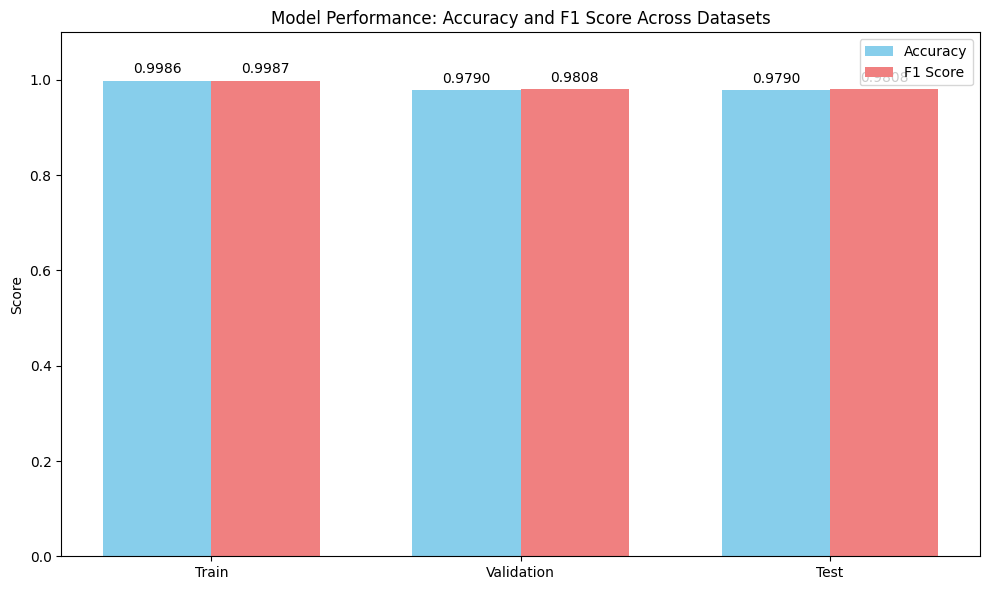

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics collected from previous steps
metrics = {
    'Train': {'Accuracy': train_results['eval_accuracy'], 'F1': train_results['eval_f1']},
    'Validation': {'Accuracy': test_results['eval_accuracy'], 'F1': test_results['eval_f1']},
    'Test': {'Accuracy': test_results['eval_accuracy'], 'F1': test_results['eval_f1']}
}

labels = list(metrics.keys())
accuracies = [metrics[label]['Accuracy'] for label in labels]
f1_scores = [metrics[label]['F1'] for label in labels]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance: Accuracy and F1 Score Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1) # Ensure y-axis starts at 0 and goes slightly above 1 for better visualization

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

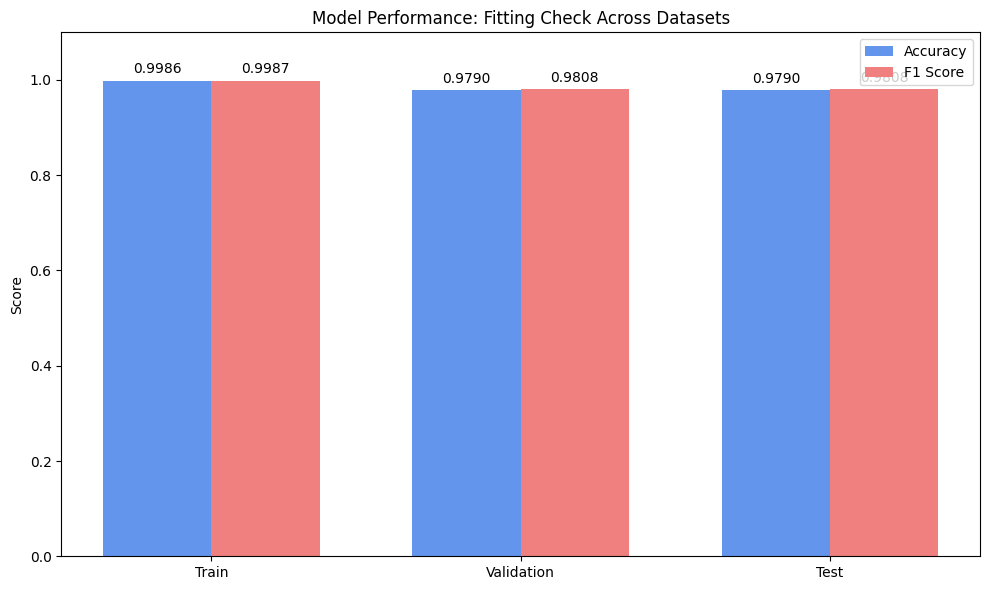

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure metrics are up-to-date from previous runs
metrics_for_graph = {
    'Train': {'Accuracy': train_results['eval_accuracy'], 'F1': train_results['eval_f1']},
    'Validation': {'Accuracy': test_results['eval_accuracy'], 'F1': test_results['eval_f1']},
    'Test': {'Accuracy': test_results['eval_accuracy'], 'F1': test_results['eval_f1']}
}

labels_graph = list(metrics_for_graph.keys())
accuracies_graph = [metrics_for_graph[label]['Accuracy'] for label in labels_graph]
f1_scores_graph = [metrics_for_graph[label]['F1'] for label in labels_graph]

x_graph = np.arange(len(labels_graph))  # the label locations
width_graph = 0.35  # the width of the bars

fig_graph, ax_graph = plt.subplots(figsize=(10, 6))
rects1_graph = ax_graph.bar(x_graph - width_graph/2, accuracies_graph, width_graph, label='Accuracy', color='cornflowerblue')
rects2_graph = ax_graph.bar(x_graph + width_graph/2, f1_scores_graph, width_graph, label='F1 Score', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax_graph.set_ylabel('Score')
ax_graph.set_title('Model Performance: Fitting Check Across Datasets')
ax_graph.set_xticks(x_graph)
ax_graph.set_xticklabels(labels_graph)
ax_graph.legend()
ax_graph.set_ylim(0, 1.1) # Ensure y-axis starts at 0 and goes slightly above 1 for better visualization

def autolabel_graph(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax_graph.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel_graph(rects1_graph)
autolabel_graph(rects2_graph)

fig_graph.tight_layout()
plt.show()